# DSE I2100: Applied Machine Learning and Data Mining
## Module 4: Data Preparation and Feature Selection

Welcome to Module 4! Real-world datasets are rarely ready for machine learning straight out of the box. Today, we will explore the critical preprocessing steps needed to build robust ML models: handling missing data, encoding categorical variables, scaling features, and evaluating feature importance.

**Run the cell below to import the necessary libraries.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# Formatting
plt.style.use('ggplot')
%matplotlib inline

## 1. Identifying and Handling Missing Data

Missing values are everywhere in applied ML. They might be caused by errors in data collection, non-applicable measurements, or unreturned surveys. Before throwing data into a model, we must locate and handle these blanks (often represented as `NaN` in pandas).

Let's construct a small toy dataset and see how to quickly drop rows or columns with missing data.

**Instruction:** Count the missing values in our DataFrame, then drop any rows containing at least one missing value.

In [2]:
csv_data = '''A,B,C,D\n1.0,2.0,3.0,4.0\n5.0,6.0,,8.0\n10.0,11.0,12.0,'''

df = pd.read_csv(StringIO(csv_data))
print("Original DataFrame:\n", df)

# Count missing values per column
print("\nMissing values per column:\n", df.isnull().sum())

# Drop rows with NaNs (axis=0 means rows)
df_dropped = df.dropna(axis=0)
print("\nDataFrame after dropping rows:\n", df_dropped)

Original DataFrame:
       A     B     C    D
0   1.0   2.0   3.0  4.0
1   5.0   6.0   NaN  8.0
2  10.0  11.0  12.0  NaN

Missing values per column:
 A    0
B    0
C    1
D    1
dtype: int64

DataFrame after dropping rows:
      A    B    C    D
0  1.0  2.0  3.0  4.0


## 2. Imputing Missing Values with Scikit-Learn

If we drop every row with a missing value, we risk throwing away a massive amount of valuable data. A better alternative is **imputation**—estimating missing values from the rest of the dataset.

A common strategy is *mean imputation*, where we replace a missing value with the mean of its entire feature column.

**Instruction:** Use `scikit-learn`'s `SimpleImputer` to replace `NaN` values with the column average. Pause and predict what the missing values will become before running the cell.

In [3]:
from sklearn.impute import SimpleImputer

# Instantiate the imputer to replace NaNs with the mean
imr = SimpleImputer(missing_values=np.nan, strategy='mean')

# Fit on the data and transform it
imputed_data = imr.fit_transform(df.values)

print("Imputed Data Array:\n", imputed_data)

Imputed Data Array:
 [[ 1.   2.   3.   4. ]
 [ 5.   6.   7.5  8. ]
 [10.  11.  12.   6. ]]


## 3. Encoding Categorical Data: Ordinal vs Nominal

Many datasets contain categorical strings. We must convert these into numbers.
* **Ordinal features** can be sorted or ordered (e.g., T-shirt sizes: M < L < XL).
* **Nominal features** imply no order (e.g., Colors: red, green, blue).

For ordinal features, we map the text to integer values manually so that the algorithm understands the numerical relationships.

**Instruction:** Create a mapping dictionary to convert string sizes into integers, then use `.map()` to apply it to the DataFrame.

In [4]:
df_cat = pd.DataFrame([
    ['green', 'M', 10.1, 'class2'],
    ['red', 'L', 13.5, 'class1'],
    ['blue', 'XL', 15.3, 'class2']
], columns=['color', 'size', 'price', 'classlabel'])

# Define the mapping dictionary based on logical order
size_mapping = {'M': 1, 'L': 2, 'XL': 3}

# Apply the mapping to the 'size' column using .map()
df_cat['size'] = df_cat['size'].map(size_mapping)
print("DataFrame after Ordinal Encoding:\n", df_cat)

DataFrame after Ordinal Encoding:
    color  size  price classlabel
0  green     1   10.1     class2
1    red     2   13.5     class1
2   blue     3   15.3     class2


## 4. One-Hot Encoding and Column Transformers

If we map nominal data (like `color`) directly to integers (0, 1, 2), algorithms like KNN might mistakenly assume that "red" is larger than "blue" or that they hold algebraic significance.

Instead, we use **One-Hot Encoding** to create dummy binary features (e.g., `color_green`, `color_red`). To prevent multicollinearity (which breaks matrix inversions in linear models), we often drop the first dummy column.

**Instruction:** Use pandas `get_dummies()` to create one-hot encoded columns for the `color` feature.

In [5]:
# Apply one-hot encoding using pandas get_dummies
# Remember to specify the columns list and drop the first column to avoid collinearity
df_encoded = pd.get_dummies(df_cat, columns=['color'], drop_first=True)
print("DataFrame after One-Hot Encoding:\n", df_encoded)

DataFrame after One-Hot Encoding:
    size  price classlabel  color_green  color_red
0     1   10.1     class2         True      False
1     2   13.5     class1        False       True
2     3   15.3     class2        False      False


## 5. Partitioning Datasets and Feature Scaling

Before measuring a model's performance, we split our data into training and testing sets.

Once split, we must apply **Feature Scaling**. Algorithms like gradient descent and KNN behave terribly if one feature is on a scale of 0-1 and another is on a scale of 1-100,000.
*Standardization* centers the features at mean 0 with a standard deviation of 1.

*Important:* We fit our scaler **only** on the training data, then use those same parameters to transform the test data. This prevents information leakage!

**Instruction:** Split the mock dataset, then standardize the training and testing arrays using `StandardScaler`.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Extract features (X) and target (y)
X = df_encoded[['size', 'price', 'color_green', 'color_red']].values
# Map class labels to 0 and 1
y = df_encoded['classlabel'].map({'class1': 0, 'class2': 1}).values

# 1. Partition into 70% train and 30% test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Instantiate and apply the StandardScaler
sc = StandardScaler()
# Fit the scaler on training data and transform it
X_train_std = sc.fit_transform(X_train)
# ONLY transform the test data using the existing scaler
X_test_std = sc.transform(X_test)

print("Standardized Training Features:\n", X_train_std)

Standardized Training Features:
 [[-1. -1.  0.  1.]
 [ 1.  1.  0. -1.]]


## 6. Assessing Feature Importance

Are all features equally useful? Usually not. Reducing dimensionality by ignoring uninformative features speeds up computation and helps avoid the "curse of dimensionality."

Tree-based models like Random Forests naturally evaluate the usefulness of a feature based on how much it decreases impurity across all trees.

**Instruction:** Fit a `RandomForestClassifier` on the standardized data and plot the `feature_importances_` array.

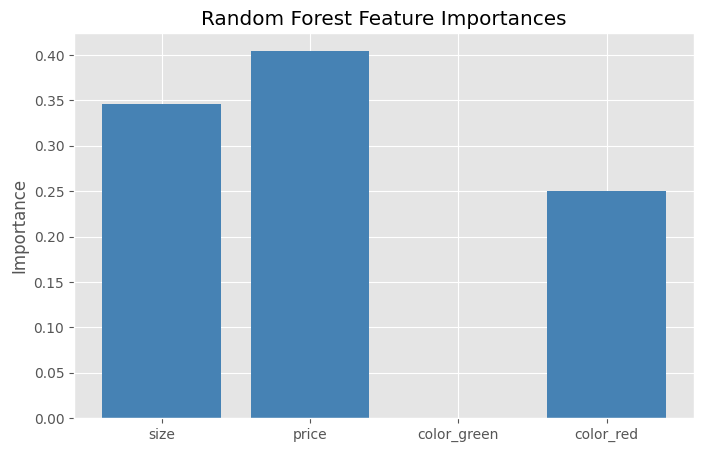

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train_std, y_train)

# Extract the importance array
importances = forest.feature_importances_
feature_names = ['size', 'price', 'color_green', 'color_red']

# Visualize
plt.figure(figsize=(8, 5))
plt.bar(feature_names, importances, color='steelblue')
plt.title('Random Forest Feature Importances')
plt.ylabel('Importance')
plt.show()